# Stock Investment Notebook

## "Higher Risk, Higher Reward!"

Refrence: https://www.investopedia.com/terms/r/riskreturntradeoff.asp

Using this method, i intent to use 25% of 250,000 for investing into such stocks. 25% will be distributed between 10 stocks and percent will be allocated depending on thier risk ratios. The 10 stock tested for this method where chossen based off of market cap. 5 of the stocks chosen had a market cap > ??? and the other 5 had a market cap < ???.

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# fix_yahoo_finance is used to fetch data 
import yfinance as yf
from pandas_datareader import data as pdr
yf.pdr_override()

In [65]:
# input
symbols = ['AAPL', 'TSLA', 'DIS', 'INTC', 'BKNG', 'NTTYY', 'BACHF', 'SYK', 'EW', 'BURL']
start = '2015-01-01'
end = '2021-11-11'

In [66]:
df = pd.DataFrame()
data = []
for symbol in symbols:
    df = pd.merge(df, pd.DataFrame(yf.download(symbol, fields='price', 
                           start=start, end=end)['Adj Close']), 
                           right_index=True, left_index=True, how='outer')
       
    # Appends tickers which have data
    data.append(symbol)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [67]:
df.columns = data
df = df.dropna(axis='columns')
df.head()

,AAPL,TSLA,DIS,INTC,BKNG,NTTYY,BACHF,SYK,EW,BURL
Date,,,,,,,,,,
2015-01-02,24.745998,43.862000,87.376251,30.078140,1142.060059,12.815,0.384714,86.516464,21.286667,47.980000
2015-01-05,24.048864,42.018002,86.099403,29.738970,1097.579956,12.580,0.384714,85.181740,21.296667,46.290001
2015-01-06,24.051128,42.256001,85.642700,29.184725,1079.959961,12.700,0.371215,85.062103,21.170000,46.570000
2015-01-07,24.388376,42.189999,86.518806,29.796865,1069.569946,12.725,0.391463,86.672966,21.666668,48.720001
2015-01-08,25.325430,42.124001,87.413536,30.351114,1082.849976,13.065,0.398213,88.145729,22.191668,48.740002


In [68]:
df.tail()

,AAPL,TSLA,DIS,INTC,BKNG,NTTYY,BACHF,SYK,EW,BURL
Date,,,,,,,,,,
2021-11-04,150.740005,1229.910034,170.279999,50.310001,2437.010010,28.670000,0.36,270.059998,117.370003,293.839996
2021-11-05,151.279999,1222.089966,175.630005,50.919998,2618.969971,28.629999,0.36,276.160004,118.650002,297.880005
2021-11-08,150.440002,1162.939941,176.869995,51.549999,2639.860107,28.520000,0.36,275.549988,119.540001,293.429993
2021-11-09,150.809998,1023.500000,175.110001,51.200001,2648.199951,28.600000,0.35,275.170013,120.040001,299.250000
2021-11-10,147.919998,1067.949951,174.449997,50.759998,2569.780029,29.110001,0.35,271.059998,118.769997,292.630005


In [69]:
df.describe()

,AAPL,TSLA,DIS,INTC,BKNG,NTTYY,BACHF,SYK,EW,BURL
count,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.00000,1728.000000,1728.000000,1728.000000,1728.000000
mean,57.749412,174.154634,118.389457,41.410110,1737.417918,22.57568,0.349445,159.957323,53.777951,146.110735
std,38.321250,242.040223,28.370748,11.396694,363.240636,2.89090,0.042400,54.630044,25.736708,81.254682
min,21.036301,28.733999,83.824928,21.890190,973.799988,12.58000,0.242977,81.786095,20.643333,40.700001
25%,28.618144,46.396499,98.900032,30.548971,1410.795013,21.16750,0.322179,108.728664,32.424168,76.787500
50%,42.106888,61.184999,107.638081,43.367485,1791.010010,22.98250,0.350000,158.952347,46.731667,140.415001
75%,71.381462,114.480001,131.980312,50.312151,1991.657501,24.28875,0.373325,200.365978,74.529999,198.007500
max,156.461655,1229.910034,201.910004,66.938637,2648.199951,29.76000,0.492704,279.431152,122.750000,352.640015


## Calculate Stock Returns

In [70]:
from IPython.display import Latex, HTML

Latex(r"""\begin{eqnarray}r_t = \frac{AdjClose_t - AdjClose_{t-1}}{AdjClose_{t-1}} = \frac{AdjClose_t}{AdjClose_{t-1}} - 1
\end{eqnarray}""")

<IPython.core.display.Latex object>

([<matplotlib.axis.YTick at 0x1d9b7214100>,
 [Text(0, 0, 'AAPL'),
  Text(0, 1, 'TSLA'),
  Text(0, 2, 'DIS'),
  Text(0, 3, 'INTC'),
  Text(0, 4, 'BKNG'),
  Text(0, 5, 'NTTYY'),
  Text(0, 6, 'BACHF'),
  Text(0, 7, 'SYK'),
  Text(0, 8, 'EW'),
  Text(0, 9, 'BURL')])

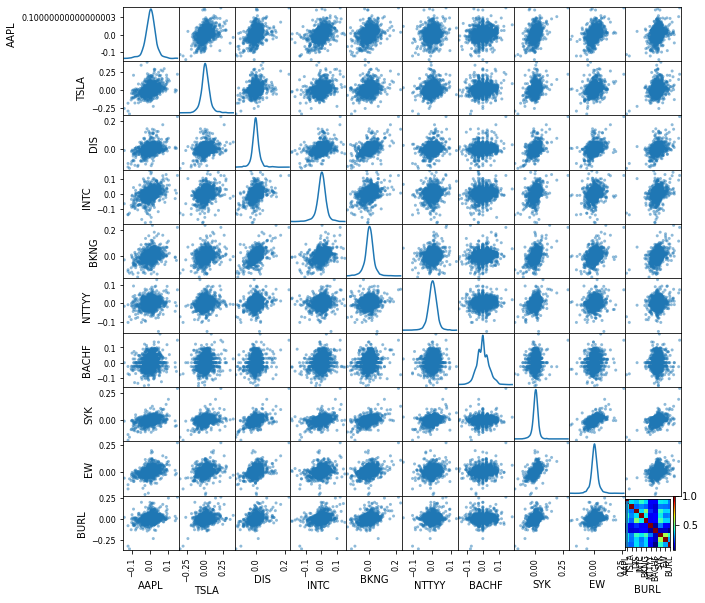

In [71]:
from pandas.plotting import scatter_matrix

rets = df.pct_change(periods=3)
scatter_matrix(rets, diagonal='kde', figsize=(10, 10))
corr = rets.corr()
plt.imshow(corr, cmap='jet', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.columns)

Text(0, 0.5, 'Standard Deviations')

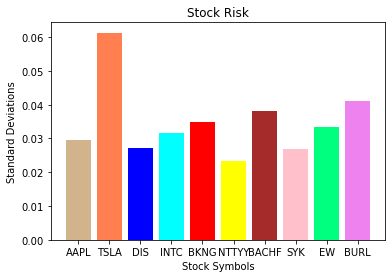

In [72]:
plt.bar(rets.columns, rets.std(), color=['tan', 'coral', 'blue', 'cyan', 'red', 'yellow', 'brown', 'pink', 'springgreen', 'violet'])
plt.title("Stock Risk")
plt.xlabel("Stock Symbols")
plt.ylabel("Standard Deviations")

Text(0, 0.5, 'Returns')

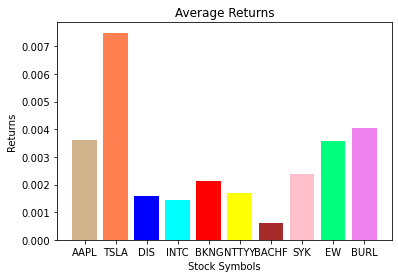

In [73]:
plt.bar(rets.columns, rets.mean(), color=['tan', 'coral', 'blue', 'cyan', 'red', 'yellow', 'brown', 'pink', 'springgreen', 'violet'])
plt.title("Average Returns")
plt.xlabel("Stock Symbols")
plt.ylabel("Returns")

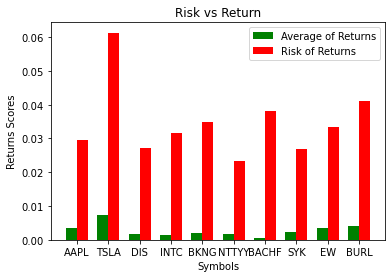

In [74]:
ind = np.arange(10)
width = 0.35       
plt.bar(ind, rets.mean(), width, color = 'g', label='Average of Returns')
plt.bar(ind + width, rets.std(), width, color = 'r', label='Risk of Returns')
plt.ylabel('Returns Scores')
plt.xlabel('Symbols')
plt.title('Risk vs Return')

plt.xticks(ind + width / 2, ('AAPL', 'TSLA', 'DIS', 'INTC', 'BKNG', 'NTTYY', 'BACHF', 'SYK', 'EW', 'BURL'))
plt.legend(loc='best')
plt.show()

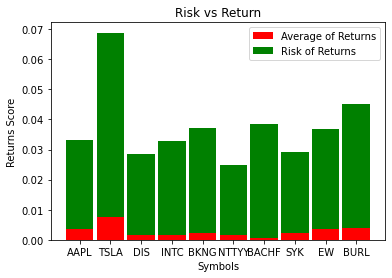

In [75]:
symbols = ['AAPL', 'TSLA', 'DIS', 'INTC', 'BKNG', 'NTTYY', 'BACHF', 'SYK', 'EW', 'BURL']
ind = [x for x, _ in enumerate(symbols)]

plt.bar(ind, rets.mean(), width=0.9, label='Average of Returns', color='r')
plt.bar(ind, rets.std(), width=0.9, label='Risk of Returns', color='g', bottom=rets.mean())

plt.xticks(ind, symbols)
plt.ylabel("Returns Score")
plt.xlabel("Symbols")
plt.legend(loc="upper right")
plt.title('Risk vs Return')
plt.show()

## Risk vs Expected Return

Table: Risk vs Expected Returns


,Risk,Expected Returns
AAPL,0.029686,0.003610
TSLA,0.061326,0.007492
DIS,0.027067,0.001596
INTC,0.031483,0.001451
BKNG,0.034964,0.002110
NTTYY,0.023257,0.001693
BACHF,0.037995,0.000593
SYK,0.026895,0.002386
EW,0.033400,0.003563
BURL,0.041032,0.004051


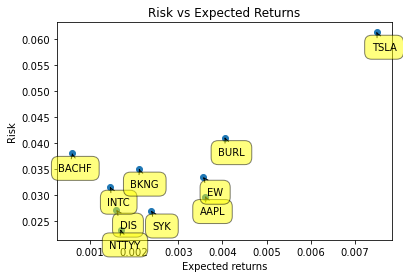

In [76]:
plt.scatter(rets.mean(), rets.std())
plt.xlabel('Expected returns')
plt.ylabel('Risk')
for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.title('Risk vs Expected Returns')
    plt.annotate(
        label, 
        xy = (x, y), xytext = (20, -20),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        bbox = dict(boxstyle = 'round,pad=0.7', fc = 'yellow', alpha = 0.5),
        arrowprops = dict(arrowstyle = '->', connectionstyle = 'arc3,rad=0'))
    
d = {'Risk':rets.std(), 'Expected Returns':rets.mean()}
print('Table: Risk vs Expected Returns')
tables = pd.DataFrame(data=d)
tables    

TSLA-7-17500
4-10000
3-7500
3-7500
2-5000
2-5000
1-2500
1-2500
1-2500
1-2500